This analysis comes from thet Network Science with Python book by David Knickerboker. Start on page 107 to 146

In [15]:
import requests
import pandas as pd
import nltk



In [16]:
url = 'https://www.gutenberg.org/files/5200/5200-0.txt'
text = requests.get(url) .text

In [17]:
cutoff = text.index('One morning')
text = text[cutoff:]

In [18]:
cutoff = text.rindex('*** END OF THE PROJECT GUTENBERG EBOOK METAMORPHOSIS ***')
text = text[:cutoff]

In [19]:
text[-500:]

'e talking, Mr. and Mrs.\r\nSamsa were struck, almost simultaneously, with the thought of how their\r\ndaughter was blossoming into a well built and beautiful young lady.\r\nThey became quieter. Just from each other’s glance and almost without\r\nknowing it they agreed that it would soon be time to find a good man\r\nfor her. And, as if in confirmation of their new dreams and good\r\nintentions, as soon as they reached their destination Grete was the\r\nfirst to get up and stretch out her young body.\r\n\r\n\r\n\r\n\r\n'

In [20]:
text = text.replace('\r', '').replace('\n', '')
#text

###Create a function that does the import, cleaning, and formating. 

In [21]:
def get_data ():
    url = 'https://www.gutenberg.org/files/5200/5200-0.txt'

    text = requests.get(url) .text

    #strip header junk
    cutoff = text.index('One morning')
    text = text[cutoff:]

    #strip footer junk
    cutoff = text.rindex('*** END OF THE PROJECT GUTENBERG EBOOK METAMORPHOSIS ***')
    text = text[:cutoff]

    #pre-processing to clean the text
    text = text.replace('\r', '').replace('\n', '')

    return text

In [22]:
text = get_data()
#text

In [23]:
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(text)
sentences[0:5]

['One morning, when Gregor Samsa woke from troubled dreams, he foundhimself transformed in his bed into a horrible vermin.',
 'He lay on hisarmour-like back, and if he lifted his head a little he could see hisbrown belly, slightly domed and divided by arches into stiff sections.The bedding was hardly able to cover it and seemed ready to slide offany moment.',
 'His many legs, pitifully thin compared with the size of therest of him, waved about helplessly as he looked.“What’s happened to me?” he thought.',
 'It wasn’t a dream.',
 'His room, aproper human room although a little too small, lay peacefully betweenits four familiar walls.']

In [24]:
nltk.pos_tag(sentences)


[('One morning, when Gregor Samsa woke from troubled dreams, he foundhimself transformed in his bed into a horrible vermin.',
  'NNP'),
 ('He lay on hisarmour-like back, and if he lifted his head a little he could see hisbrown belly, slightly domed and divided by arches into stiff sections.The bedding was hardly able to cover it and seemed ready to slide offany moment.',
  'NNP'),
 ('His many legs, pitifully thin compared with the size of therest of him, waved about helplessly as he looked.“What’s happened to me?” he thought.',
  'NNP'),
 ('It wasn’t a dream.', 'NNP'),
 ('His room, aproper human room although a little too small, lay peacefully betweenits four familiar walls.',
  'NNP'),
 ('A collection of textile samples lay spread outon the table—Samsa was a travelling salesman—and above it there hung apicture that he had recently cut out of an illustrated magazine andhoused in a nice, gilded frame.',
  'NNP'),
 ('It showed a lady fitted out with a furhat and fur boa who sat upright, 

In [25]:
sentence = sentences[0]
sentence

'One morning, when Gregor Samsa woke from troubled dreams, he foundhimself transformed in his bed into a horrible vermin.'

In [26]:
from nltk.tokenize import casual_tokenize

tokens = casual_tokenize(sentence)

tokens

['One',
 'morning',
 ',',
 'when',
 'Gregor',
 'Samsa',
 'woke',
 'from',
 'troubled',
 'dreams',
 ',',
 'he',
 'foundhimself',
 'transformed',
 'in',
 'his',
 'bed',
 'into',
 'a',
 'horrible',
 'vermin',
 '.']

In [27]:
nltk.pos_tag(tokens)

[('One', 'CD'),
 ('morning', 'NN'),
 (',', ','),
 ('when', 'WRB'),
 ('Gregor', 'NNP'),
 ('Samsa', 'NNP'),
 ('woke', 'VBD'),
 ('from', 'IN'),
 ('troubled', 'JJ'),
 ('dreams', 'NNS'),
 (',', ','),
 ('he', 'PRP'),
 ('foundhimself', 'VBD'),
 ('transformed', 'VBN'),
 ('in', 'IN'),
 ('his', 'PRP$'),
 ('bed', 'NN'),
 ('into', 'IN'),
 ('a', 'DT'),
 ('horrible', 'JJ'),
 ('vermin', 'NN'),
 ('.', '.')]

In [28]:
entities = []
for row in nltk.pos_tag(tokens):
    token = row[0]
    tag = row[1]
    if tag == 'NNP':
        entities.append(token)

entities

['Gregor', 'Samsa']

In [29]:
def extract_entities (sentence):
    entities = []
    tokens = casual_tokenize(sentence)
    for row in nltk.pos_tag(tokens):
        token = row[0]
        tag = row[1]
        if tag == 'NNP':
            entities.append(token)
    if len(entities) > 0:
        return entities
    
    else:
        return None
    
entities = [extract_entities(sentence) for sentence in sentences]
entities

[['Gregor', 'Samsa'],
 None,
 ['’'],
 None,
 None,
 ['Samsa'],
 None,
 ['’'],
 None,
 ['Oh', 'God', '”'],
 None,
 ['Hell'],
 None,
 None,
 None,
 None,
 None,
 None,
 ['’'],
 ['Isuppose', '’'],
 None,
 ['First', 'God', 'Heaven'],
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 ['’', 'Gregor', '’'],
 ['’'],
 None,
 ['Gregor', '’'],
 None,
 ['Gregor'],
 None,
 ['Gregor', '”'],
 ['Didn', '’'],
 ['Gregor'],
 None,
 ['Gregorhad', 'Gregor', '’'],
 ['Gregor'],
 ['Gregor', 'Gregor', '”', '’', 'Gregor'],
 ['Gregor'],
 ['Aren', '’', 'Gregor'],
 ['Gregor', 'Gregor'],
 ['Onlythen'],
 None,
 None,
 None,
 None,
 ['Ifhe'],
 ['Gregor'],
 None,
 None,
 None,
 None,
 None,
 None,
 ['Seven', '“', '’', '’', 'Andhe'],
 ['’', '’'],
 None,
 None,
 ['Gregor'],
 None,
 None,
 None,
 None,
 None,
 ['”', 'Gregor'],
 ['’'],
 ['Gregor'],
 ['’'],
 ['—'],
 None,
 ['Gregor', '’'],
 ['”'],
 ['Gregor'],
 ['’'],
 ['Gregor', '’', 'Gregor', 'Yes', 'Gregor', 'Gregor', '”'],
 None,
 None,
 None,
 ['Mr', 'Samsa', '”'],
 [

In [30]:
df = pd.DataFrame({'sentence':sentences, 'entities':entities})
df.head(10)

,sentence,entities
0,"One morning, when Gregor Samsa woke from troub...","[Gregor, Samsa]"
1,"He lay on hisarmour-like back, and if he lifte...",None
2,"His many legs, pitifully thin compared with th...",[’]
3,It wasn’t a dream.,None
4,"His room, aproper human room although a little...",None
5,A collection of textile samples lay spread out...,[Samsa]
6,It showed a lady fitted out with a furhat and ...,None
7,"Drops ofrain could be heard hitting the pane, ...",[’]
8,"However hard he threw himself onto hisright, h...",None
9,"He must have tried it ahundred times, shut his...","[Oh, God, ”]"


In [31]:
df = df.dropna()
df = df[df['entities'].apply(len) > 1]
entities = df['entities'].to_list()
entities

[['Gregor', 'Samsa'],
 ['Oh', 'God', '”'],
 ['Isuppose', '’'],
 ['First', 'God', 'Heaven'],
 ['’', 'Gregor', '’'],
 ['Gregor', '’'],
 ['Gregor', '”'],
 ['Didn', '’'],
 ['Gregorhad', 'Gregor', '’'],
 ['Gregor', 'Gregor', '”', '’', 'Gregor'],
 ['Aren', '’', 'Gregor'],
 ['Gregor', 'Gregor'],
 ['Seven', '“', '’', '’', 'Andhe'],
 ['’', '’'],
 ['”', 'Gregor'],
 ['Gregor', '’'],
 ['Gregor', '’', 'Gregor', 'Yes', 'Gregor', 'Gregor', '”'],
 ['Mr', 'Samsa', '”'],
 ['Gregor', 'Gregor'],
 ['Mrs', 'Samsa', '”', 'Canthe'],
 ['No', '”', 'Gregor'],
 ['“', 'Mr'],
 ['Samsa', '”'],
 ['Mr.Samsa', 'Sir', '”', 'Gregor'],
 ['Gregor', '’', '’'],
 ['Did', '“'],
 ['Oh', 'God'],
 ['Gregoris', 'Quick'],
 ['Did', 'Gregor', '’'],
 ['Listen', '”', 'Gregor', 'Well', 'Gregor', '”'],
 ['Gregor', '’'],
 ['’', '’'],
 ['Gregor', 'Gregor'],
 ['”', 'Gregor'],
 ['’', '’'],
 ['Butyou', '’'],
 ['Andyou', '’', '’', '’', '’'],
 ['Please', 'Gregor'],
 ['Help', '’', 'Help', 'Gregor', 'Mother', 'Gregor'],
 ['Gregor', '’'],
 ['Grego

In [32]:
import spacy
nlp = spacy.load("en_core_web_md")

In [33]:
doc = nlp(text)
sentences = list(doc.sents)

In [34]:
for s in sentences[0:6]:
    print(s)
    print()

One morning, when Gregor Samsa woke from troubled dreams, he foundhimself transformed in his bed into a horrible vermin.

He lay on hisarmour-like back, and if he lifted his head a little he could see hisbrown belly, slightly domed and divided by arches into stiff sections.

The bedding was hardly able to cover it and seemed ready to slide offany moment.

His many legs, pitifully thin compared with the size of therest of him, waved about helplessly as he looked.

“What’s happened to me?” he thought.

It wasn’t a dream.



In [35]:
for token in sentences[0]:
    print('{}: {}' .format(token.text, token.tag_))

One: CD
morning: NN
,: ,
when: WRB
Gregor: NNP
Samsa: NNP
woke: VBD
from: IN
troubled: JJ
dreams: NNS
,: ,
he: PRP
foundhimself: PRP
transformed: VBD
in: IN
his: PRP$
bed: NN
into: IN
a: DT
horrible: JJ
vermin: NN
.: .


In [36]:
for token in sentences[0]:
    print('{}: {}' .format(token.text, token.pos_))

One: NUM
morning: NOUN
,: PUNCT
when: SCONJ
Gregor: PROPN
Samsa: PROPN
woke: VERB
from: ADP
troubled: ADJ
dreams: NOUN
,: PUNCT
he: PRON
foundhimself: PRON
transformed: VERB
in: ADP
his: PRON
bed: NOUN
into: ADP
a: DET
horrible: ADJ
vermin: NOUN
.: PUNCT


In [37]:
entities = []
for token in sentences[0]:
    if token.tag_ == 'NNP':
        entities.append(token.text)

entities

['Gregor', 'Samsa']

In [38]:
def extract_entities(text):
    doc = nlp(text)
    sentences = list(doc.sents)
    entities = []
    for sentence in sentences:
        sentence_entities = []
        for token in sentence:
            if token.tag_ == 'NNP':
                sentence_entities.append(token.text)
        if len(sentence_entities) > 0:
            entities.append(sentence_entities)
    return entities

In [39]:
extract_entities(text)

[['Gregor', 'Samsa'],
 ['Samsa'],
 ['boa'],
 ['Gregor'],
 ['God'],
 ['Hell'],
 ['guest'],
 ['Isuppose'],
 ['“God', 'Heaven'],
 ['Gregor’snot'],
 ['Gregor'],
 ['thedoctor'],
 ['Gregor'],
 ['Gregor', 'mother—“it'],
 ['Gregor'],
 ['Gregorhad'],
 ['Gregor'],
 ['Gregor'],
 ['Gregor', 'Gregor'],
 ['Gregor', 'Gregor'],
 ['Gregor'],
 ['Gregor'],
 ['Gregor'],
 ['Gregor', 'hadno'],
 ['Hewould'],
 ['Ifhe'],
 ['Gregor'],
 ['himthat'],
 ['thischaos'],
 ['Gregor', 'andforth'],
 ['swang'],
 ['Gregor'],
 ['Gregor'],
 ['Gregor'],
 ['“Something'],
 ['Gregor'],
 ['Gregor', 'Gregor', 'chiefclerk'],
 ['Gregor'],
 ['chiefclerk'],
 ['Mr.', 'Samsa'],
 ['Gregor'],
 ['Hisidea'],
 ['Gregor'],
 ['Gregor'],
 ['Gregor'],
 ['Mrs.', 'Samsa'],
 ['Gregor'],
 ['Gregor'],
 ['Gregor'],
 ['Gregor'],
 ['Mr.', 'Samsa', 'him,“what'],
 ['theway'],
 ['Iam'],
 ['Mr.', 'Samsa', '”“But'],
 ['Sir', 'Gregor'],
 ['I’dthought'],
 ['sir', 'Gregor'],
 ['Gregor'],
 ['o’clock'],
 ['Grete'],
 ['Grete'],
 ['Gregoris', 'ill'],
 ['Quick'],
 [

In [40]:
for token in sentences[0]:
    print('{}: {}' .format(token.text, token.ent_type_))

One: TIME
morning: TIME
,: 
when: 
Gregor: PERSON
Samsa: PERSON
woke: 
from: 
troubled: 
dreams: 
,: 
he: 
foundhimself: 
transformed: 
in: 
his: 
bed: 
into: 
a: 
horrible: 
vermin: 
.: 


In [41]:
def get_data():
    url = 'https://www.gutenberg.org/files/11/11-0.txt'

    text = requests.get(url) .text

    #strip header junk
    cutoff = text.index('Alice was beginning')
    text = text[cutoff:]

    #strip footer junk
    cutoff = text.rindex('THE END')
    text = text[:cutoff]

    #pre-processing to clean the text
    text = text.replace('\r', ' ') .replace('\n', ' ')
    text = text.replace('â\x80\x99', '\'') .replace('â\x80\x9c', '"') .replace('â\x80\x9d', '""') .replace('â\x80\x94', ' ')

    return text



In [42]:
text = get_data()
#text

In [43]:
alice_entities = extract_entities(text)
alice_entities[0:10]

[['Alice', 'Alice'],
 ['White', 'Rabbit'],
 ['Alice'],
 ['Rabbit'],
 ['Rabbit', 'Alice'],
 ['Alice'],
 ['Alice'],
 ['ORANGE', 'MARMALADE'],
 ['Alice'],
 ['Alice']]

In [44]:
final_source = []
final_targets = []
for row in alice_entities:
    source = row[0]
    targets = row[1:]
    for target in targets:
        final_source.append(source)
        final_targets.append(target)

In [45]:
final_source[0:5]
final_targets[0:5]

['Alice', 'Rabbit', 'Alice', 'MARMALADE', 'Longitude']

In [46]:
def get_network_data(entities):
    final_sources = []
    final_targets = []
    for row in alice_entities:
        source = row[0]
        targets = row[1:]
        for target in targets:
            final_sources.append(source)
            final_targets.append(target)
    df = pd.DataFrame({'source':final_sources, 'target':final_targets})
    return df

In [47]:
alice_network_df = get_network_data(alice_entities)
alice_network_df.head()

,source,target
0,Alice,Alice
1,White,Rabbit
2,Rabbit,Alice
3,ORANGE,MARMALADE
4,Latitude,Longitude


In [48]:
import networkx as nx
G_alice = nx.from_pandas_edgelist(alice_network_df)

In [93]:
import numpy as np
import networkx as nx
from IPython.display import SVG
from sknetwork.visualization import svg_graph
from sknetwork.data import Bunch
from sknetwork.ranking import PageRank
from scipy.sparse import csr_matrix


def draw_graph(G, show_names=False, node_size=1, font_size=10, edge_width=0.5):
    # Force explicit CSR sparse matrix format
    adjacency = nx.to_scipy_sparse_array(G, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency)  # Ensure it's in scipy sparse format

    # Maintain consistent node order
    node_list = list(G.nodes())
    names = np.array(node_list)

    # Create graph bundle
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = names

    # Compute PageRank using sknetwork
    pagerank = PageRank()
    pagerank.fit(adjacency)
    scores = pagerank.scores_

    # Draw the graph
    if show_names:
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size,
                          names=graph.names, width=700, height=500, scores=scores,
                          edge_width=edge_width)
    else:
        image = svg_graph(graph.adjacency, node_size=node_size, width=700,
                          height=500, scores=scores, edge_width=edge_width)

    return SVG(image)


In [99]:
def draw_ego_graph(G, node, center=True, k=0, show_names=True, edge_width=0.1, node_size=3, font_size=12):
    # Extract ego subgraph centered at 'node'
    ego_subgraph = nx.ego_graph(G, node, center=center)
    
    # Optionally extract the k-core of the ego subgraph
    if k > 0:
        ego_subgraph = nx.k_core(ego_subgraph, k=k)
    
    # Visualize using draw_graph
    return draw_graph(ego_subgraph, node_size=node_size, font_size=font_size,
                      show_names=show_names, edge_width=edge_width)


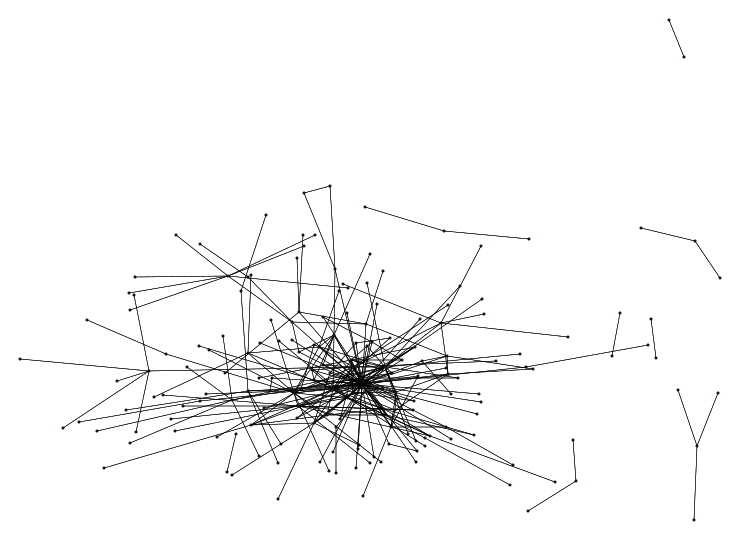

In [95]:
draw_graph(G_alice)

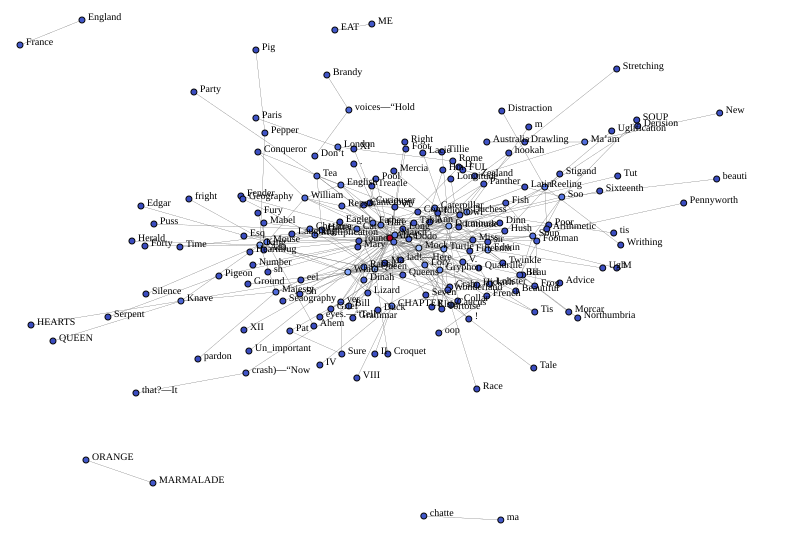

In [96]:
draw_graph(G_alice, edge_width=0.2, node_size=3, show_names=True)

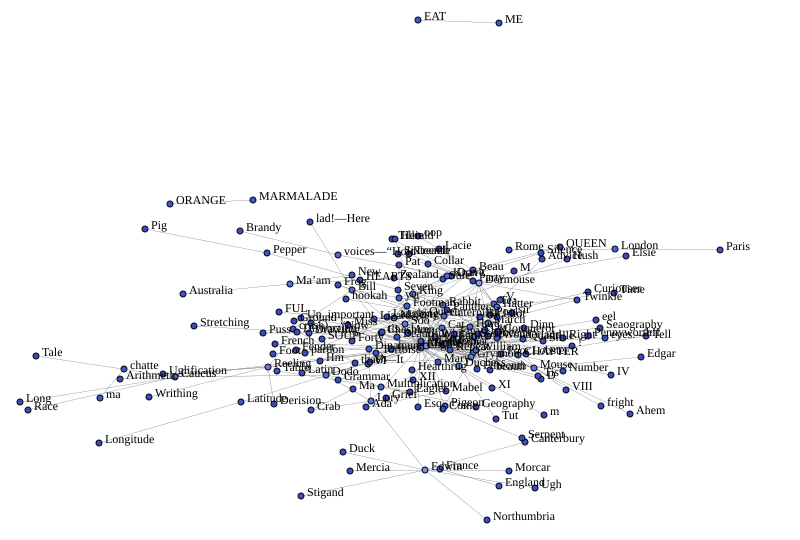

In [97]:
draw_graph(G_alice, edge_width=0.2, node_size=3, show_names=True, font_size=12)

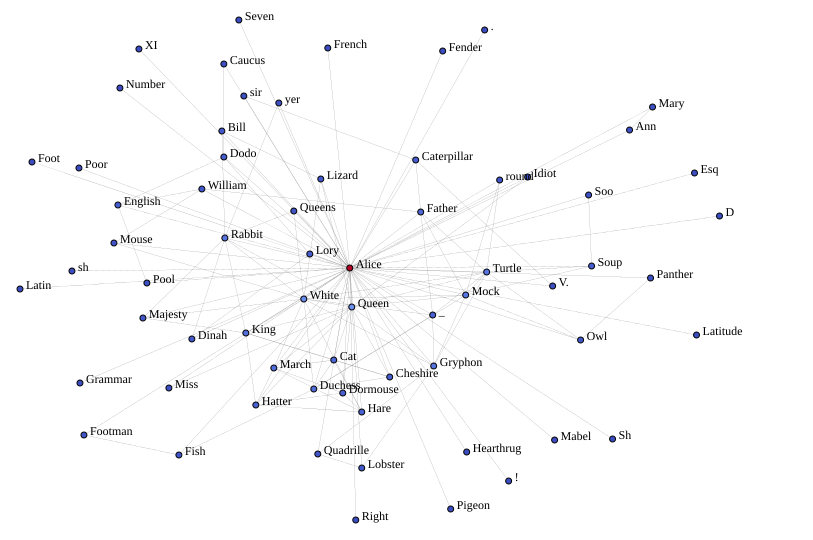

In [100]:
draw_ego_graph(G_alice, 'Alice')